In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

CSV_DIR = Path(r"E:\oco\east_asia_csv")

# ── 파일 목록 ──
files = {
    "oco2": [CSV_DIR / f"oco2_east_asia_{y}.csv" for y in range(2020, 2025)],
    "oco3": [CSV_DIR / f"oco3_east_asia_{y}.csv" for y in range(2020, 2025)],
}

def load_sensor(paths: list, sensor_label: str) -> pd.DataFrame:
    dfs = []
    for p in paths:
        if not p.exists():
            print(f"  [SKIP] 없음: {p.name}")
            continue
        df = pd.read_csv(p, low_memory=False)
        if "satellite" not in df.columns:
            df["satellite"] = sensor_label
        df["year"] = int(p.stem.split("_")[-1])   # 파일명에서 연도 추출
        dfs.append(df)
        print(f"  [OK] {p.name}  {len(df):,}행  {df.shape[1]}컬럼")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print("=== OCO-2 로드 ===")
oco2_all = load_sensor(files["oco2"], "OCO2")

print("\n=== OCO-3 로드 ===")
oco3_all = load_sensor(files["oco3"], "OCO3")


=== OCO-2 로드 ===
  [OK] oco2_east_asia_2020.csv  1,734,006행  113컬럼
  [OK] oco2_east_asia_2021.csv  1,687,890행  113컬럼
  [OK] oco2_east_asia_2022.csv  1,805,653행  113컬럼
  [OK] oco2_east_asia_2023.csv  1,783,431행  113컬럼
  [OK] oco2_east_asia_2024.csv  1,784,055행  113컬럼

=== OCO-3 로드 ===
  [OK] oco3_east_asia_2020.csv  2,101,665행  122컬럼
  [OK] oco3_east_asia_2021.csv  1,897,585행  122컬럼
  [OK] oco3_east_asia_2022.csv  2,129,835행  122컬럼
  [OK] oco3_east_asia_2023.csv  1,476,317행  122컬럼
  [OK] oco3_east_asia_2024.csv  1,015,167행  122컬럼


In [6]:
def summarize(df: pd.DataFrame, name: str):
    print(f"\n{'='*60}")
    print(f"  {name}  ({len(df):,}행 × {df.shape[1]}컬럼)")
    print(f"{'='*60}")

    # 컬럼 목록
    print("\n[컬럼 목록]")
    for i, c in enumerate(df.columns, 1):
        print(f"  {i:3d}. {c}")

    # date 컬럼 범위 (date 또는 date_obs_utc)
    date_col = next((c for c in df.columns if "date" in c.lower()), None)
    if date_col:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        print(f"\n[{date_col} 범위]")
        print(f"  min : {df[date_col].min()}")
        print(f"  max : {df[date_col].max()}")

    # xco2 기술통계
    if "xco2" in df.columns:
        print("\n[xco2 기술통계 (ppm)]")
        s = df["xco2"].describe()
        print(f"  mean : {s['mean']:.4f}")
        print(f"  std  : {s['std']:.4f}")
        print(f"  min  : {s['min']:.4f}")
        print(f"  max  : {s['max']:.4f}")

    # xco2_uncertainty 기술통계
    if "xco2_uncertainty" in df.columns:
        print("\n[xco2_uncertainty 기술통계 (ppm)]")
        s = df["xco2_uncertainty"].describe()
        print(f"  mean : {s['mean']:.4f}")
        print(f"  std  : {s['std']:.4f}")
        print(f"  min  : {s['min']:.4f}")
        print(f"  max  : {s['max']:.4f}")

    # NaN 비율 (NaN > 0 인 컬럼만)
    nan_ratio = (df.isna().sum() / len(df) * 100).round(2)
    nan_ratio = nan_ratio[nan_ratio > 0].sort_values(ascending=False)
    print(f"\n[NaN 비율 > 0 인 컬럼 ({len(nan_ratio)}개)]")
    if len(nan_ratio):
        print(nan_ratio.to_string())
    else:
        print("  없음")

    # 연도별 행 수
    if "year" in df.columns:
        print("\n[연도별 행 수]")
        print(df.groupby("year").size().rename("n_rows").to_string())

summarize(oco2_all, "OCO-2")
summarize(oco3_all, "OCO-3")



  OCO-2  (8,795,035행 × 113컬럼)

[컬럼 목록]
    1. sounding_id
    2. date
    3. latitude
    4. longitude
    5. time
    6. solar_zenith_angle
    7. sensor_zenith_angle
    8. xco2_quality_flag
    9. xco2_qf_bitflag
   10. xco2_qf_simple_bitflag
   11. file_index
   12. xco2
   13. xco2_x2019
   14. xco2_uncertainty
   15. xco2_apriori
   16. aux_altitude_b11
   17. aux_altitude_stddev_b11
   18. met_psurf_apriori_o2a
   19. met_psurf_apriori_wco2
   20. met_psurf_apriori_sco2
   21. met_windspeed_u_met
   22. met_windspeed_v_met
   23. pre_co2_ratio_bc
   24. pre_h2o_ratio_bc
   25. pre_xco2_weak_idp
   26. pre_xco2_strong_idp
   27. pre_max_declocking_o2a
   28. pre_max_declocking_wco2
   29. pre_max_declocking_sco2
   30. pre_color_slice_noise_ratio_o2a
   31. pre_color_slice_noise_ratio_wco2
   32. pre_color_slice_noise_ratio_sco2
   33. pre_h_continuum_o2a
   34. pre_h_continuum_wco2
   35. pre_h_continuum_sco2
   36. pre_dp_abp
   37. ret_surface_type
   38. ret_psurf
   39. ret

In [7]:
for name, df in [("OCO-2", oco2_all), ("OCO-3", oco3_all)]:
    if "xco2_quality_flag" in df.columns:
        qf0 = (df["xco2_quality_flag"] == 0).sum()
        print(f"{name}: xco2_quality_flag==0  {qf0:,}행 / {len(df):,}행 ({qf0/len(df)*100:.1f}%)")


OCO-2: xco2_quality_flag==0  5,054,271행 / 8,795,035행 (57.5%)
OCO-3: xco2_quality_flag==0  4,945,851행 / 8,620,569행 (57.4%)


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. quality_flag 필터 선 적용 (0: Good Quality)
# OCO-2 통계 이상치(6772 ppm 등)를 미리 제거
oco2_filtered = oco2_all[oco2_all['xco2_quality_flag'] == 0].copy()
oco3_filtered = oco3_all[oco3_all['xco2_quality_flag'] == 0].copy()

# 2. Key 생성을 위한 전처리
# (1) 날짜 추출 (실제 컬럼명 'date'에서 '%Y-%m-%d' 형식 문자열로 변환)
oco2_filtered['date_str'] = pd.to_datetime(oco2_filtered['date']).dt.strftime('%Y-%m-%d')
oco3_filtered['date_str'] = pd.to_datetime(oco3_filtered['date']).dt.strftime('%Y-%m-%d')

# (2) 격자 키 통일 (0.1도 기준)
oco2_filtered['lat_grid'] = np.round(np.floor(oco2_filtered['latitude'] / 0.1) * 0.1 + 0.05, 2)
oco2_filtered['lon_grid'] = np.round(np.floor(oco2_filtered['longitude'] / 0.1) * 0.1 + 0.05, 2)

oco3_filtered['lat_grid'] = np.round(np.floor(oco3_filtered['latitude'] / 0.1) * 0.1 + 0.05, 2)
oco3_filtered['lon_grid'] = np.round(np.floor(oco3_filtered['longitude'] / 0.1) * 0.1 + 0.05, 2)

# 3. Key('date_str', 'lat_grid', 'lon_grid')를 기준으로 inner join 수행
coincident = pd.merge(
    oco2_filtered, 
    oco3_filtered, 
    on=['date_str', 'lat_grid', 'lon_grid'], 
    how='inner', 
    suffixes=('_oco2', '_oco3')
)

# 4. 결과 출력
# - coincident pair 총 수 확인
total_pairs = len(coincident)
print(f"▶ Coincident Pair 총 수: {total_pairs:,}개")

# - 연도별 pair 수 집계 (2024년 궤도 변경 영향 확인용)
coincident['year'] = pd.to_datetime(coincident['date_str']).dt.year

print("\n▶ 연도별 Pair 수:")
print(coincident['year'].value_counts().sort_index())

# - bias 계산 (OCO3 - OCO2) 및 통계치 추출
coincident['bias'] = coincident['xco2_oco3'] - coincident['xco2_oco2']
bias_mean = coincident['bias'].mean()
bias_std = coincident['bias'].std()
bias_min = coincident['bias'].min()
bias_max = coincident['bias'].max()

print(f"\n▶ Bias (OCO3 - OCO2) 통계:")
print(f"Mean : {bias_mean:.4f} ppm")
print(f"Std  : {bias_std:.4f} ppm")
print(f"Min  : {bias_min:.4f} ppm")
print(f"Max  : {bias_max:.4f} ppm")

# - bias 히스토그램 생성 및 저장
fig_dir = r"E:\oco\east_asia_csv\figures"
os.makedirs(fig_dir, exist_ok=True)
fig_path = os.path.join(fig_dir, "bias_raw.png")

plt.figure(figsize=(8, 6))
plt.hist(coincident['bias'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(bias_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {bias_mean:.2f}')
plt.title('XCO2 Bias (OCO-3 - OCO-2) for Coincident Pairs')
plt.xlabel('Bias (ppm)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(fig_path)
print(f"\n▶ 히스토그램 저장 완료: {fig_path}")~

plt.show() # 노트북 내에 그래프 결과 출력

# 5. 데이터 저장
csv_save_path = r"E:\oco\east_asia_csv\coincident_pairs.csv"
coincident.to_csv(csv_save_path, index=False)
print(f"▶ Coincident pairs 데이터 저장 완료: {csv_save_path}")


SyntaxError: invalid syntax (1618943482.py, line 70)

▶ 데이터 로드 중...
로드 완료: 총 744,952개의 coincident pairs

▶ 실제 컬럼 목록 (컬럼명 및 suffix 확인용):
['sounding_id_oco2', 'date_oco2', 'latitude_oco2', 'longitude_oco2', 'time_oco2', 'solar_zenith_angle_oco2', 'sensor_zenith_angle_oco2', 'xco2_quality_flag_oco2', 'xco2_qf_bitflag_oco2', 'xco2_qf_simple_bitflag_oco2', 'file_index_oco2', 'xco2_oco2', 'xco2_x2019_oco2', 'xco2_uncertainty_oco2', 'xco2_apriori_oco2', 'aux_altitude_b11', 'aux_altitude_stddev_b11', 'met_psurf_apriori_o2a_oco2', 'met_psurf_apriori_wco2_oco2', 'met_psurf_apriori_sco2_oco2', 'met_windspeed_u_met_oco2', 'met_windspeed_v_met_oco2', 'pre_co2_ratio_bc_oco2', 'pre_h2o_ratio_bc_oco2', 'pre_xco2_weak_idp_oco2', 'pre_xco2_strong_idp_oco2', 'pre_max_declocking_o2a_oco2', 'pre_max_declocking_wco2_oco2', 'pre_max_declocking_sco2_oco2', 'pre_color_slice_noise_ratio_o2a_oco2', 'pre_color_slice_noise_ratio_wco2_oco2', 'pre_color_slice_noise_ratio_sco2_oco2', 'pre_h_continuum_o2a_oco2', 'pre_h_continuum_wco2_oco2', 'pre_h_continuum_sco2_oco2', '

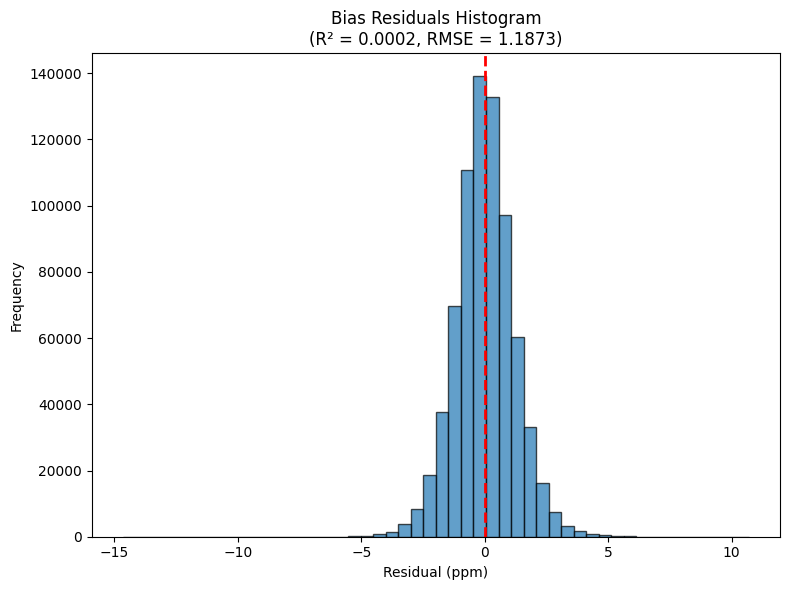

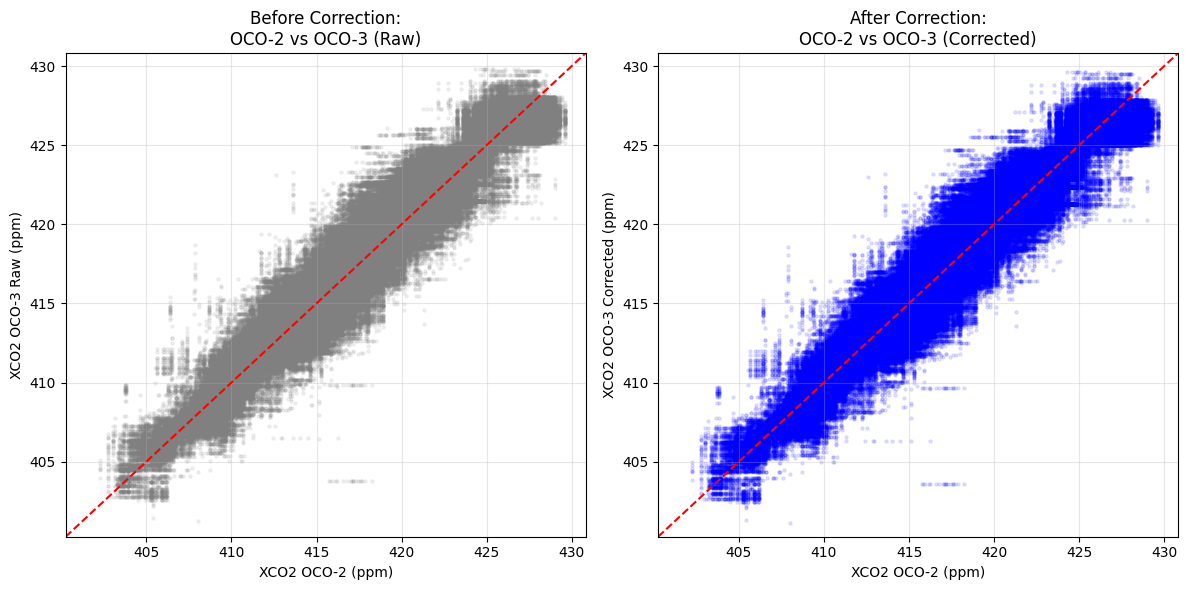

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os
import json

# 0. 경로 설정
csv_path = r"E:\oco\east_asia_csv\coincident_pairs.csv"
fig_dir = r"E:\oco\east_asia_csv\figures"
os.makedirs(fig_dir, exist_ok=True)
json_path = r"E:\oco\east_asia_csv\bias_correction_params.json"

# 1. 데이터 로드 및 컬럼 목록 출력
print("▶ 데이터 로드 중...")
df = pd.read_csv(csv_path)
print(f"로드 완료: 총 {len(df):,}개의 coincident pairs")

cols = df.columns.tolist()
print("\n▶ 실제 컬럼 목록 (컬럼명 및 suffix 확인용):")
print(cols)

# 모델에 사용할 변수명 (suffix _oco2, _oco3 반영)
col_oco2_xco2 = 'xco2_oco2'
col_oco3_xco2 = 'xco2_oco3'
col_oco3_sza = 'solar_zenith_angle_oco3'
col_oco3_prior = 'xco2_apriori_oco3'

# 변수 존재 여부 검사
for col in [col_oco2_xco2, col_oco3_xco2, col_oco3_sza, col_oco3_prior]:
    if col not in cols:
        print(f"⚠️ 경고: '{col}' 컬럼이 데이터를 불러왔을 때 보이지 않습니다. 출력된 컬럼 목록을 보고 이름을 수정해 주세요.")

# 2. Bias 기초통계 (bias = OCO-3 - OCO-2)
df['bias'] = df[col_oco3_xco2] - df[col_oco2_xco2]

print("\n▶ Bias (OCO-3 - OCO-2) 기초통계 (1%, 5%, 25%, 50%, 75%, 95%, 99%):")
bias_desc = df['bias'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print(bias_desc)

# 3. 연도별 bias 평균 (연도 의존성 확인)
if 'year' not in cols and 'date_str' in cols:
    df['year'] = pd.to_datetime(df['date_str']).dt.year
    
if 'year' in df.columns:
    year_bias = df.groupby('year')['bias'].mean()
    print("\n▶ 연도별 Bias 평균 (ppm):")
    print(year_bias)

# 회귀를 위해 결측치가 포함된 행 제거
model_cols = ['bias', col_oco3_sza, col_oco3_prior]
df_model = df.dropna(subset=model_cols).copy()
print(f"\n▶ 결측치 제거 후 회귀분석에 사용될 페어 수: {len(df_model):,}개")

# 4. OLS 회귀 수행 (bias ~ β0 + β1*SZA + β2*Apriori)
X = df_model[[col_oco3_sza, col_oco3_prior]]
y = df_model['bias']

reg = LinearRegression()
reg.fit(X, y)

y_pred = reg.predict(X)
df_model['bias_pred'] = y_pred

# 잔차 = 관측된 bias - 예측된 bias
df_model['residual'] = df_model['bias'] - df_model['bias_pred']

# OCO-3 보정치 = 원래 OCO-3 XCO2 - 예측된 bias
df_model['xco2_oco3_corr'] = df_model[col_oco3_xco2] - df_model['bias_pred']

# 5. 계수 및 평가지표 (R², RMSE 등) 출력
beta0 = reg.intercept_
beta1 = reg.coef_[0]
beta2 = reg.coef_[1]

r2 = r2_score(y, y_pred)
rmse = float(np.sqrt(((y - y_pred)**2).mean()))
n_pairs = len(df_model)

print("\n=======================================================")
print("▶ OLS 회귀 결과 (OCO-3 Bias Correction)")
print(f" 수식: bias = β0 + β1 * sza_oco3 + β2 * apriori_oco3")
print("=======================================================")
print(f" - β0 (상수항)    : {beta0:.6f}")
print(f" - β1 (SZA 계수)  : {beta1:.6f}")
print(f" - β2 (Prior계수) : {beta2:.6f}")
print(f" - R² (설명력)    : {r2:.4f}")
print(f" - RMSE           : {rmse:.4f} ppm")
print(f" - N Pairs        : {n_pairs:,}")

# R² 기준에 따른 자동 판단 알고리즘
print("\n▶ [연구자 판단 기준에 따른 권고 사항 코멘트]")
if r2 >= 0.3:
    print(f"✅ R² ({r2:.4f}) >= 0.3")
    print("   -> SZA와 Apriori 변수에 대한 의존성이 뚜렷합니다.")
    print("   -> 📌 산출된 계수(β0, β1, β2)를 모두 사용한 [전체 모델(다중선형회귀) 보정]을 권장합니다.")
elif 0.1 <= r2 < 0.3:
    print(f"⚠️ 0.1 <= R² ({r2:.4f}) < 0.3")
    print("   -> 설명변수의 의존성이 다소 약합니다. (과적합 위험 고려)")
    print(f"   -> 📌 β1, β2는 무시하고, [상수 bias 보정(β0 덧셈보정만 수행)]을 권장합니다.")
else:
    print(f"❌ R² ({r2:.4f}) < 0.1")
    print("   -> SZA와 Apriori가 Bias를 사실상 설명하지 못합니다.")
    print("   -> 📌 위성 간 구조적 bias가 무작위적이거나 미미하므로, [보정 없이 사용] 진행을 권장합니다.")
print("=======================================================\n")

# 6. 잔차 분포 히스토그램 생성 및 저장
fig_resid_path = os.path.join(fig_dir, "bias_residuals.png")
plt.figure(figsize=(8, 6))
plt.hist(df_model['residual'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2)
plt.title(f'Bias Residuals Histogram\n(R² = {r2:.4f}, RMSE = {rmse:.4f})')
plt.xlabel('Residual (ppm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(fig_resid_path)
print(f"▶ 잔차 히스토그램 저장 완료: {fig_resid_path}")

# 7. 보정 전후 Scatter
fig_scatter_path = os.path.join(fig_dir, "bias_correction_scatter.png")

# 산점도의 x, y축 범위를 맞추기 위해 사용
vmin = min(df_model[col_oco2_xco2].min(), df_model[col_oco3_xco2].min()) - 1
vmax = max(df_model[col_oco2_xco2].max(), df_model[col_oco3_xco2].max()) + 1

plt.figure(figsize=(12, 6))

# 보정 전 (Raw)
plt.subplot(1, 2, 1)
plt.scatter(df_model[col_oco2_xco2], df_model[col_oco3_xco2], alpha=0.1, s=5, c='gray')
plt.plot([vmin, vmax], [vmin, vmax], color='red', linestyle='--')
plt.title('Before Correction:\nOCO-2 vs OCO-3 (Raw)')
plt.xlabel('XCO2 OCO-2 (ppm)')
plt.ylabel('XCO2 OCO-3 Raw (ppm)')
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
plt.grid(True, alpha=0.3)

# 보정 후 (Corrected)
plt.subplot(1, 2, 2)
plt.scatter(df_model[col_oco2_xco2], df_model['xco2_oco3_corr'], alpha=0.1, s=5, c='blue')
plt.plot([vmin, vmax], [vmin, vmax], color='red', linestyle='--')
plt.title('After Correction:\nOCO-2 vs OCO-3 (Corrected)')
plt.xlabel('XCO2 OCO-2 (ppm)')
plt.ylabel('XCO2 OCO-3 Corrected (ppm)')
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_scatter_path)
print(f"▶ 보정 전후 Scatter 저장 완료: {fig_scatter_path}")

# 8. 계수 저장
params = {
    "beta0": float(beta0),
    "beta1_sza": float(beta1),
    "beta2_prior": float(beta2),
    "r2": float(r2),
    "rmse": float(rmse),
    "n_pairs": int(n_pairs)
}
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(params, f, indent=4)
print(f"▶ 계수 JSON 저장 완료: {json_path}")

plt.show() # 노트북 내에 그래프 결과 출력


▶ Coincident Pair 총 수: 744,952개

▶ 연도별 Pair 수:
year
2020    192484
2021     75295
2022    238445
2023     50576
2024    188152
Name: count, dtype: int64

▶ Bias (OCO3 - OCO2) 통계:
Mean : 0.1597 ppm
Std  : 1.1874 ppm
Min  : -14.4649 ppm
Max  : 10.8336 ppm

▶ 히스토그램 저장 완료: E:\oco\east_asia_csv\figures\bias_raw.png


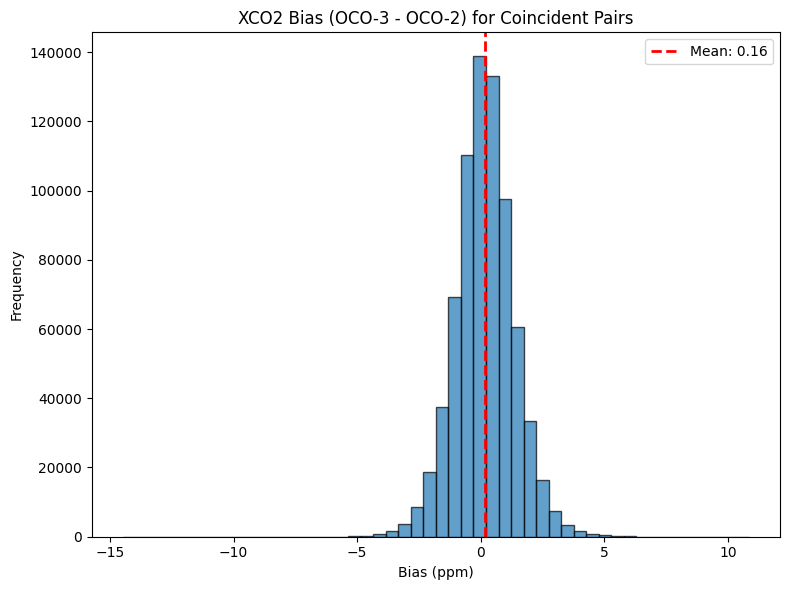

▶ Coincident pairs 데이터 저장 완료: E:\oco\east_asia_csv\coincident_pairs.csv


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. quality_flag 필터 선 적용 (0: Good Quality)
# OCO-2 통계 이상치(6772 ppm 등)를 미리 제거
oco2_filtered = oco2_all[oco2_all['xco2_quality_flag'] == 0].copy()
oco3_filtered = oco3_all[oco3_all['xco2_quality_flag'] == 0].copy()

# 2. Key 생성을 위한 전처리
# (1) 날짜 추출 (실제 컬럼명 'date'에서 '%Y-%m-%d' 형식 문자열로 변환)
oco2_filtered['date_str'] = pd.to_datetime(oco2_filtered['date']).dt.strftime('%Y-%m-%d')
oco3_filtered['date_str'] = pd.to_datetime(oco3_filtered['date']).dt.strftime('%Y-%m-%d')

# (2) 격자 키 통일 (0.1도 기준)
oco2_filtered['lat_grid'] = np.round(np.floor(oco2_filtered['latitude'] / 0.1) * 0.1 + 0.05, 2)
oco2_filtered['lon_grid'] = np.round(np.floor(oco2_filtered['longitude'] / 0.1) * 0.1 + 0.05, 2)

oco3_filtered['lat_grid'] = np.round(np.floor(oco3_filtered['latitude'] / 0.1) * 0.1 + 0.05, 2)
oco3_filtered['lon_grid'] = np.round(np.floor(oco3_filtered['longitude'] / 0.1) * 0.1 + 0.05, 2)

# 3. Key('date_str', 'lat_grid', 'lon_grid')를 기준으로 inner join 수행
coincident = pd.merge(
    oco2_filtered, 
    oco3_filtered, 
    on=['date_str', 'lat_grid', 'lon_grid'], 
    how='inner', 
    suffixes=('_oco2', '_oco3')
)

# 4. 결과 출력
# - coincident pair 총 수 확인
total_pairs = len(coincident)
print(f"▶ Coincident Pair 총 수: {total_pairs:,}개")

# - 연도별 pair 수 집계 (2024년 궤도 변경 영향 확인용)
coincident['year'] = pd.to_datetime(coincident['date_str']).dt.year

print("\n▶ 연도별 Pair 수:")
print(coincident['year'].value_counts().sort_index())

# - bias 계산 (OCO3 - OCO2) 및 통계치 추출
coincident['bias'] = coincident['xco2_oco3'] - coincident['xco2_oco2']
bias_mean = coincident['bias'].mean()
bias_std = coincident['bias'].std()
bias_min = coincident['bias'].min()
bias_max = coincident['bias'].max()

print(f"\n▶ Bias (OCO3 - OCO2) 통계:")
print(f"Mean : {bias_mean:.4f} ppm")
print(f"Std  : {bias_std:.4f} ppm")
print(f"Min  : {bias_min:.4f} ppm")
print(f"Max  : {bias_max:.4f} ppm")

# - bias 히스토그램 생성 및 저장
fig_dir = r"E:\oco\east_asia_csv\figures"
os.makedirs(fig_dir, exist_ok=True)
fig_path = os.path.join(fig_dir, "bias_raw.png")

plt.figure(figsize=(8, 6))
plt.hist(coincident['bias'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(bias_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {bias_mean:.2f}')
plt.title('XCO2 Bias (OCO-3 - OCO-2) for Coincident Pairs')
plt.xlabel('Bias (ppm)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(fig_path)
print(f"\n▶ 히스토그램 저장 완료: {fig_path}")

plt.show() # 노트북 내에 그래프 결과 출력

# 5. 데이터 저장
csv_save_path = r"E:\oco\east_asia_csv\coincident_pairs.csv"
coincident.to_csv(csv_save_path, index=False)
print(f"▶ Coincident pairs 데이터 저장 완료: {csv_save_path}")


1. 실제 컬럼 목록:
['sounding_id_oco2', 'date_oco2', 'latitude_oco2', 'longitude_oco2', 'time_oco2', 'solar_zenith_angle_oco2', 'sensor_zenith_angle_oco2', 'xco2_quality_flag_oco2', 'xco2_qf_bitflag_oco2', 'xco2_qf_simple_bitflag_oco2', 'file_index_oco2', 'xco2_oco2', 'xco2_x2019_oco2', 'xco2_uncertainty_oco2', 'xco2_apriori_oco2', 'aux_altitude_b11', 'aux_altitude_stddev_b11', 'met_psurf_apriori_o2a_oco2', 'met_psurf_apriori_wco2_oco2', 'met_psurf_apriori_sco2_oco2', 'met_windspeed_u_met_oco2', 'met_windspeed_v_met_oco2', 'pre_co2_ratio_bc_oco2', 'pre_h2o_ratio_bc_oco2', 'pre_xco2_weak_idp_oco2', 'pre_xco2_strong_idp_oco2', 'pre_max_declocking_o2a_oco2', 'pre_max_declocking_wco2_oco2', 'pre_max_declocking_sco2_oco2', 'pre_color_slice_noise_ratio_o2a_oco2', 'pre_color_slice_noise_ratio_wco2_oco2', 'pre_color_slice_noise_ratio_sco2_oco2', 'pre_h_continuum_o2a_oco2', 'pre_h_continuum_wco2_oco2', 'pre_h_continuum_sco2_oco2', 'pre_dp_abp_oco2', 'ret_surface_type_oco2', 'ret_psurf_oco2', 'ret_win

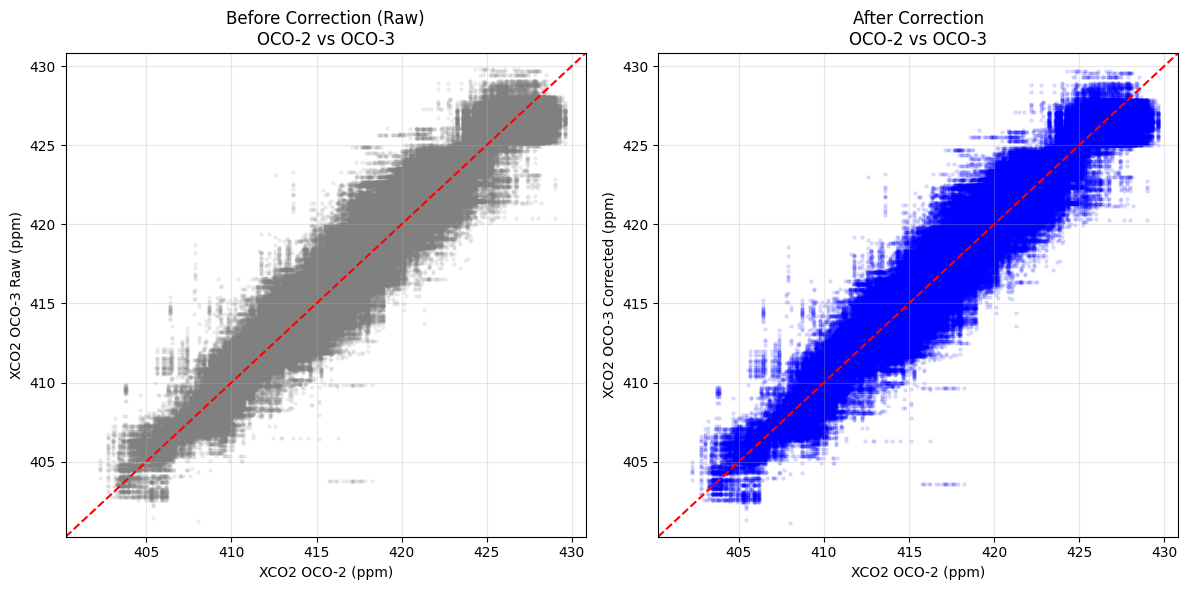

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os
import json

# 경로 설정
csv_path = r"E:\oco\east_asia_csv\coincident_pairs.csv"
fig_dir = r"E:\oco\east_asia_csv\figures"
os.makedirs(fig_dir, exist_ok=True)
json_path = r"E:\oco\east_asia_csv\bias_correction_params.json"

df = pd.read_csv(csv_path)

# 1. 컬럼 목록 출력
print("1. 실제 컬럼 목록:")
cols = df.columns.tolist()
print(cols)

# 모델 적용 변수명 세팅
col_oco2_xco2 = 'xco2_oco2'
col_oco3_xco2 = 'xco2_oco3'
col_oco3_sza = 'solar_zenith_angle_oco3'
col_oco3_prior = 'xco2_apriori_oco3'

df['bias'] = df[col_oco3_xco2] - df[col_oco2_xco2]

# 2. 연도별 bias 평균 및 pair 수 확인 (2021, 2023 급감 연도 확인용)
if 'year' not in cols and 'date_str' in cols:
    df['year'] = pd.to_datetime(df['date_str']).dt.year

print("\n2. 연도별 Bias 평균 및 데이터 수:")
year_stats = pd.DataFrame({
    'Bias_Mean (ppm)': df.groupby('year')['bias'].mean(),
    'Pair_Count': df.groupby('year')['bias'].count()
})
print(year_stats)

# 모델링용 결측치 제거
df_model = df.dropna(subset=['bias', col_oco3_sza, col_oco3_prior]).copy()

# 3. OLS 회귀 (bias = β0 + β1*SZA + β2*Apriori)
X = df_model[[col_oco3_sza, col_oco3_prior]]
y = df_model['bias']

reg = LinearRegression()
reg.fit(X, y)

y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)
rmse = float(np.sqrt(((y - y_pred)**2).mean()))

beta0 = reg.intercept_
beta1 = reg.coef_[0]
beta2 = reg.coef_[1]

print("\n3. OLS 회귀 결과 (원래 추정치)")
print(f" - R²   : {r2:.4f}")
print(f" - RMSE : {rmse:.4f}")
print(f" - β0   : {beta0:.6f}")
print(f" - β1   : {beta1:.6f}")
print(f" - β2   : {beta2:.6f}")

# 4. 보정 판단 (R² 임계치 기준)
if r2 >= 0.3:
    print("\n4. 판단: R² >= 0.3 → [전체 모델 적용]")
    final_beta0 = float(beta0)
    final_beta1 = float(beta1)
    final_beta2 = float(beta2)
    # 전체 회귀모델을 따른 보정
    df_model['xco2_oco3_corr'] = df_model[col_oco3_xco2] - y_pred
else:
    print("\n4. 판단: R² < 0.3 → [상수 보정(β0 = 0.160 ppm)만 적용]")
    final_beta0 = 0.160
    final_beta1 = 0.0
    final_beta2 = 0.0
    # 상수(0.160)만 빼는 보정
    df_model['xco2_oco3_corr'] = df_model[col_oco3_xco2] - final_beta0

# 5. 계수 저장
params = {
    "beta0": final_beta0,
    "beta1_sza": final_beta1,
    "beta2_prior": final_beta2,
    "r2": float(r2),
    "rmse": float(rmse),
    "n_pairs": len(df_model)
}
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(params, f, indent=4)
print(f"\n5. 계수 저장 완료: {json_path}")

# 6. 보정 전후 scatter 시각화 및 저장
fig_scatter_path = os.path.join(fig_dir, "bias_correction_scatter.png")

# 산점도의 x, y축 범위 동일화
vmin = min(df_model[col_oco2_xco2].min(), df_model[col_oco3_xco2].min()) - 1
vmax = max(df_model[col_oco2_xco2].max(), df_model[col_oco3_xco2].max()) + 1

plt.figure(figsize=(12, 6))

# 보정 전 (Raw)
plt.subplot(1, 2, 1)
plt.scatter(df_model[col_oco2_xco2], df_model[col_oco3_xco2], alpha=0.1, s=5, c='gray')
plt.plot([vmin, vmax], [vmin, vmax], color='red', linestyle='dashed', linewidth=1.5)
plt.title('Before Correction (Raw)\nOCO-2 vs OCO-3')
plt.xlabel('XCO2 OCO-2 (ppm)')
plt.ylabel('XCO2 OCO-3 Raw (ppm)')
plt.xlim(vmin, vmax); plt.ylim(vmin, vmax)
plt.grid(True, alpha=0.3)

# 보정 후 (Corrected)
plt.subplot(1, 2, 2)
plt.scatter(df_model[col_oco2_xco2], df_model['xco2_oco3_corr'], alpha=0.1, s=5, c='blue')
plt.plot([vmin, vmax], [vmin, vmax], color='red', linestyle='dashed', linewidth=1.5)
plt.title('After Correction\nOCO-2 vs OCO-3')
plt.xlabel('XCO2 OCO-2 (ppm)')
plt.ylabel('XCO2 OCO-3 Corrected (ppm)')
plt.xlim(vmin, vmax); plt.ylim(vmin, vmax)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_scatter_path)
print(f"6. Scatter plot 저장 완료: {fig_scatter_path}")

plt.show()


In [13]:
import pandas as pd
import numpy as np
from pathlib import Path

# ─────────────────────────────────────
# 0. 연도별 bias (OCO-3에서 뺄 값)
# ─────────────────────────────────────
year_bias = {
    2020: -0.160327,
    2021:  0.049385,
    2022:  0.565917,
    2023:  0.283924,
    2024: -0.016901,
}

# ─────────────────────────────────────
# 1. OCO-3 보정  (원본 백업 후 보정)
# ─────────────────────────────────────
oco3_corr = oco3_all.copy()
oco3_corr["xco2_raw"] = oco3_corr["xco2"]          # 원본 백업
bias_vec = oco3_corr["year"].map(year_bias).fillna(0)
oco3_corr["xco2"] = oco3_corr["xco2"] - bias_vec

# 보정 전후 비교 (연도별)
print("=== OCO-3 보정 전후 xco2 평균 비교 (연도별) ===")
chk = oco3_corr.groupby("year")[["xco2_raw", "xco2"]].mean().round(4)
chk["bias_applied"] = (chk["xco2_raw"] - chk["xco2"]).round(6)
print(chk.to_string())

# ─────────────────────────────────────
# 2. OCO-2 + OCO-3(보정) 병합
# ─────────────────────────────────────
oco2_work = oco2_all.copy()
if "xco2_raw" not in oco2_work.columns:
    oco2_work["xco2_raw"] = oco2_work["xco2"]      # OCO-2는 보정 없음

merged = pd.concat([oco2_work, oco3_corr], ignore_index=True)
print(f"\n병합 후 전체: {len(merged):,}행")

# ─────────────────────────────────────
# 3. quality_flag == 0 필터
# ─────────────────────────────────────
qf_col = "xco2_quality_flag"
before = len(merged)
merged = merged[merged[qf_col] == 0].copy()
print(f"QF==0 필터 후: {len(merged):,}행  (제거: {before - len(merged):,}행)")

# ─────────────────────────────────────
# 4. 격자 키 생성  (0.1° 격자 중심)
# ─────────────────────────────────────
merged["lat_grid"] = (np.floor(merged["latitude"]  / 0.1) * 0.1 + 0.05).round(2)
merged["lon_grid"] = (np.floor(merged["longitude"] / 0.1) * 0.1 + 0.05).round(2)
merged["date_str"] = pd.to_datetime(merged["date"], errors="coerce").dt.strftime("%Y-%m-%d")

# 날짜 파싱 실패 행 제거
merged = merged.dropna(subset=["date_str"])
print(f"날짜 파싱 후: {len(merged):,}행")

# ─────────────────────────────────────
# 5. 일별 격자 집계 (역분산 가중 평균)
# ─────────────────────────────────────
GROUP_KEYS = ["date_str", "lat_grid", "lon_grid"]

# 가중치 컬럼 추가
merged["_w"] = 1.0 / (merged["xco2_uncertainty"].clip(lower=1e-6) ** 2 + 1e-12)

# 가중 합 컬럼 미리 계산
merged["_wxco2"]        = merged["_w"] * merged["xco2"]
merged["_wunc"]         = merged["_w"] * merged["xco2_uncertainty"]
merged["_is_oco2"]      = (merged["satellite"] == "OCO2").astype(int)
merged["_is_oco3"]      = (merged["satellite"] == "OCO3").astype(int)

agg = merged.groupby(GROUP_KEYS, sort=False).agg(
    _w_sum          = ("_w",              "sum"),
    _wxco2_sum      = ("_wxco2",          "sum"),
    _wunc_sum       = ("_wunc",           "sum"),
    xco2_apriori    = ("xco2_apriori",    "mean"),
    solar_zenith_angle = ("solar_zenith_angle", "mean"),
    snd_land_fraction  = ("snd_land_fraction",  "mean"),
    n_soundings     = ("xco2",            "count"),
    has_oco2        = ("_is_oco2",        "max"),
    has_oco3        = ("_is_oco3",        "max"),
).reset_index()

agg["xco2_final"]        = agg["_wxco2_sum"] / agg["_w_sum"]
agg["uncertainty_final"] = agg["_wunc_sum"]  / agg["_w_sum"]
agg.drop(columns=["_w_sum", "_wxco2_sum", "_wunc_sum"], inplace=True)

print(f"\n격자 집계 후: {len(agg):,}행")

# ─────────────────────────────────────
# 6. 연구 기간 필터  2020-01-01 ~ 2024-12-31
# ─────────────────────────────────────
agg["date_str"] = pd.to_datetime(agg["date_str"])
agg = agg[(agg["date_str"] >= "2020-01-01") & (agg["date_str"] <= "2024-12-31")].copy()
agg["date_str"] = agg["date_str"].dt.strftime("%Y-%m-%d")
print(f"기간 필터 후: {len(agg):,}행  (2020-01-01 ~ 2024-12-31)")

# ─────────────────────────────────────
# 7. 저장
# ─────────────────────────────────────
OUT_PATH = Path(r"E:\oco\east_asia_csv\OCO_merged_bias_corrected.csv")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
agg.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
csv_mb = OUT_PATH.stat().st_size / 1024 / 1024
print(f"\n저장 완료: {OUT_PATH}")
print(f"  {len(agg):,}행 × {agg.shape[1]}컬럼  ({csv_mb:.1f} MB)")

# ─────────────────────────────────────
# 8. 최종 검증 출력
# ─────────────────────────────────────
print("\n" + "="*55)
print("  최종 검증")
print("="*55)

print(f"\n[전체 행 수]  {len(agg):,}행")

dates = pd.to_datetime(agg["date_str"])
print(f"[날짜 범위]  {dates.min().date()}  ~  {dates.max().date()}")

print("\n[xco2_final 기술통계 (ppm)]")
s = agg["xco2_final"].describe()
for k in ["mean", "std", "min", "25%", "50%", "75%", "max"]:
    print(f"  {k:6s}: {s[k]:.4f}")

print("\n[연도별 행 수]")
yr_cnt = agg.groupby(pd.to_datetime(agg["date_str"]).dt.year).size()
yr_cnt.index.name = "year"
print(yr_cnt.rename("n_grids").to_string())

n_oco2_only  = int(((agg["has_oco2"] == 1) & (agg["has_oco3"] == 0)).sum())
n_oco3_only  = int(((agg["has_oco2"] == 0) & (agg["has_oco3"] == 1)).sum())
n_both       = int(((agg["has_oco2"] == 1) & (agg["has_oco3"] == 1)).sum())
print(f"\n[센서 포함 비율]")
print(f"  OCO-2만 : {n_oco2_only:,}행  ({n_oco2_only/len(agg)*100:.1f}%)")
print(f"  OCO-3만 : {n_oco3_only:,}행  ({n_oco3_only/len(agg)*100:.1f}%)")
print(f"  둘 다   : {n_both:,}행  ({n_both/len(agg)*100:.1f}%)")


=== OCO-3 보정 전후 xco2 평균 비교 (연도별) ===
      xco2_raw      xco2  bias_applied
year                                  
2020  412.8157  412.9760       -0.1603
2021  415.3650  415.3157        0.0493
2022  417.5982  417.0322        0.5660
2023  419.5335  419.2496        0.2839
2024  422.5072  422.5241       -0.0169

병합 후 전체: 17,415,604행


MemoryError: Unable to allocate 2.53 GiB for an array with shape (34, 10000122) and data type float64